In [ ]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
#Load Dataset
df = pd.read_csv("egg_freshness_dataset_v2.csv")

X = df[['NH3_ppm', 'Lux', 'Temp_C', 'RH_pct', 'Day']]
y = df['FreshnessLabel']

In [ ]:
#Preprocessing and Splitting
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
#LR
model = LogisticRegression(max_iter=1000, multi_class='multinomial')
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [ ]:
#Accuracy
y_pred = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")

Accuracy: 97.3 %


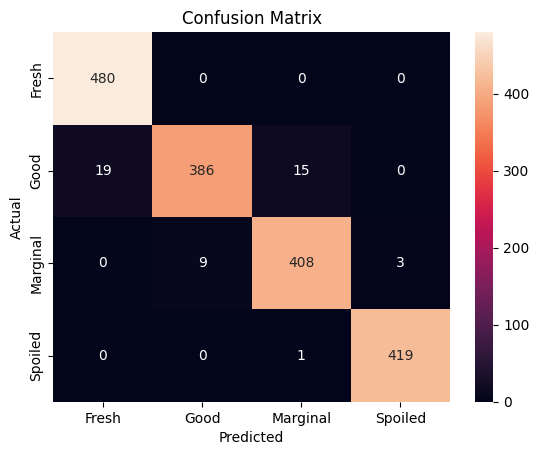

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = model.classes_

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

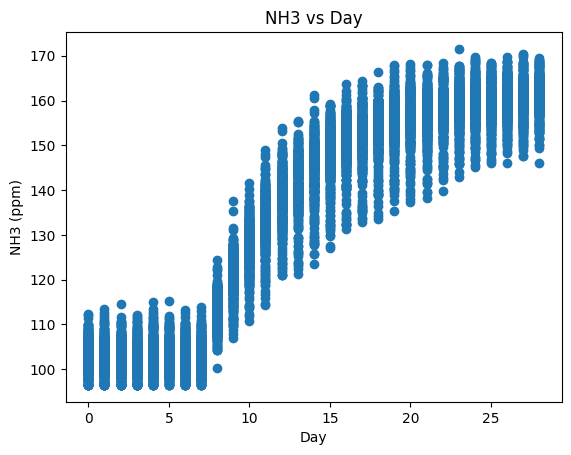

In [ ]:
#NH3 vs Day
plt.figure()
plt.scatter(df['Day'], df['NH3_ppm'])
plt.xlabel("Day")
plt.ylabel("NH3 (ppm)")
plt.title("NH3 vs Day")
plt.show()

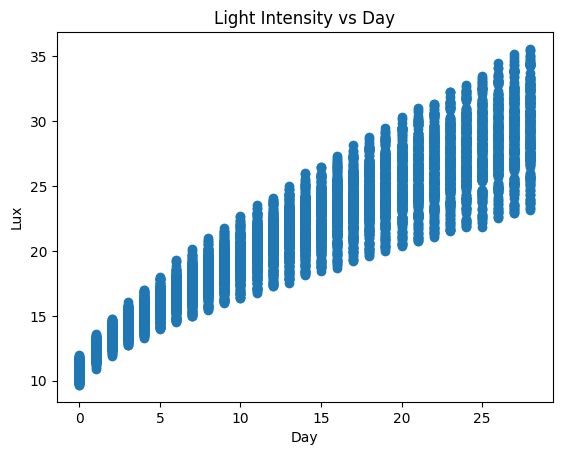

In [ ]:
#Light Intensity vs Day
plt.figure()
plt.scatter(df['Day'], df['Lux'])
plt.xlabel("Day")
plt.ylabel("Lux")
plt.title("Light Intensity vs Day")
plt.show()

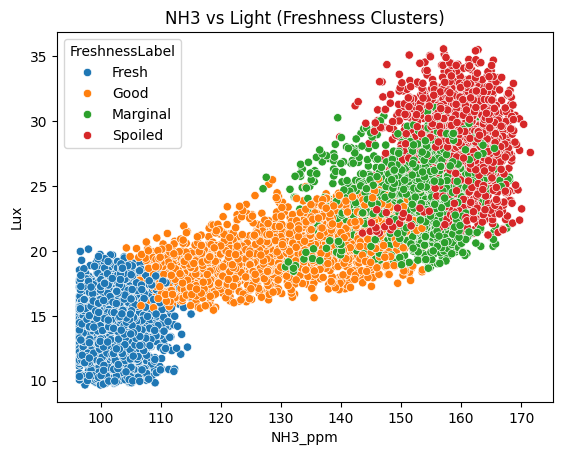

In [ ]:
#NH3 vs Light Intensity
plt.figure()
sns.scatterplot(x=df['NH3_ppm'], y=df['Lux'], hue=df['FreshnessLabel'])
plt.title("NH3 vs Light (Freshness Clusters)")
plt.show()

In [ ]:
#Testing with New Data
sample = [[140.5, 21.2, 24.1, 75.3, 13]]
sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)
print("Prediction:", prediction[0])

Prediction: Good


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))